# Introduction
Information Retrieval (IR) is a field of study dedicated to the organization and retrieval of information from vast and diverse collections of data. In the context of digital information, IR involves the development of techniques and systems that enable users to efficiently access relevant information. Key tasks in IR include indexing, searching, and ranking documents based on their relevance to user queries.

This assignment delves into various aspects of Information Retrieval, exploring fundamental concepts and practical applications. Throughout the assignment, we will examine techniques for document indexing, retrieval models, and the evaluation of IR systems using metrics such as precision, recall, and mean average precision. By delving into these topics, we aim to gain a comprehensive understanding of the core principles that govern effective information retrieval.



In this lab, you are going to implement a standard document processing pipeline and then build a simple search engine based on it:

- Building an inverted index,
- Answering queries using this index with various retrieval models.
- Evaluate the models implemented.

This assignment is based on a subset of the TREC 2003 Web Topic Distillation will be employed, featuring a curated subset of the WT10g (Web Track 10 gigabyte) corpus as the document collection. This chosen dataset will serve as the foundation for rigorously assessing the performance of the implemented Information Retrieval models. Utilizing a well-established benchmark such as TREC ensures a standardized and meaningful evaluation, allowing for robust comparisons between different models.


You can locate the necessary data in the following locations:

- **Data Folder:** 'government_data'
- **Documents Folder:** 'documents'
- **Topics (Queries) File:** 'gov.topics'
  - *Format:* Each line follows the pattern `<query_id> <query_text>`
- **Qrels (Query Relevance Judgements) File:** 'gov.qrels'
  - *Format:* Each line follows the pattern `<query_id> 0 <doc_id> <relevance>`
    - `<query_id>`: The unique identifier for the query.
    - `Q0`: A literal indicating the query and is usually constant.
    - `<doc_id>`: The identifier of the retrieved document.
    - `<rank>`: The rank assigned to the document by the retrieval system.
    - `<score>`: The retrieval score assigned to the document by the system.
    - `<run_id>`: A unique identifier for the run or retrieval system.  


In [1]:
import nltk
import os
from collections import Counter
from tqdm import tqdm
import math
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize

nltk.download('punkt')  # Download the punkt tokenizer models


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Preprocessing

First, we need a unified approach to documents and queries preprocessing. Implement a class responsible for that. Complete the code for given functions (most of them are just one-liners) and make sure you pass the tests. Make use of nltk library, spacy, or any other you know.

### <span style="color:red"><b>TASK 1</b></span>


Let's first implement the functions **tokenize** and **stem** for respectively tokenizing and steeming.



In [4]:
class Preprocessor:
    """
    A class for text preprocessing tasks such as tokenization, stemming, and filtering stop words.

    Attributes:
        stop_words (set): A set of common stop words to be filtered out during tokenization.
        ps (nltk.stem.PorterStemmer): An instance of the Porter Stemmer for word stemming.
    """
    def __init__(self,stop_words=None, stemmer=nltk.stem.PorterStemmer()):
        """
        Initializes the Preprocessor object by defining the set of stop words and creating a Porter Stemmer instance.
        """
        if stop_words is None:
            self.stop_words = { 'a', 'an', 'and', 'are', 'as', 'at', 'be', 'by',
                                'for', 'from', 'has', 'he', 'in', 'is', 'it', 'its',
                                'of', 'on', 'that', 'the', 'to', 'was',
                                'were', 'will', 'with'}
        else:
            self.stop_words = stop_words
        self.stemmer = stemmer

    def tokenize(self, text):
        """
        This function tokenizes the input text into words using the NLTK (Natural Language Toolkit)
        word tokenizer. The NLTK word tokenizer is capable of handling various types of text,
        including contractions and punctuations, and produces a list of individual words.

        Parameters:
            text (str): The input text to be tokenized.

        Returns:
            list: A list of tokens obtained by splitting the input text into words.

        """
        ## START YOU CODE HERE
        tokenized_text = word_tokenize(text)
        ## END
        return tokenized_text

    def stem(self, token):
        """
        This function utilizes the Porter Stemmer algorithm to reduce the input token
        to its root or base form. Stemming is a common text processing technique that
        helps in simplifying words to their common base, enhancing the efficiency and
        effectiveness of text analysis tasks.

        Parameters:
            token (str): The token to be stemmed.

        Returns:
            str: The stemmed version of the input token.

        """
        ## START YOU CODE HERE
        stemmed_token = self.stemmer.stem(token)
        ## END
        return stemmed_token


    def is_apt_word(self, token):
        """
        This function determines the appropriateness of a token based on two criteria:
            1. It should consist of letters only (not include punctuation, numbers, or dates).
            2. It should not be a common stop word.

        Parameters:
            token (str): The token to be checked.

        Returns:
            bool: True if the token consists of letters only and is not a stop word,
                  False otherwise.
        """
        if token.isalpha() and token.lower() not in self.stop_words:
            return True
        else:
            return False


    def preprocess(self, text, lower=True):
        """
        This function preprocesses the input text by first tokenizing it and optionally converting
        it to lowercase. Then, it removes any inappropriate words (stop words, non-letter characters)
        and applies stemming to the remaining tokens.

        Parameters:
            text (str): The input text to be preprocessed.
            lower (bool, optional): If True, converts the text to lowercase before processing.
                                     Default is True.

        Returns:
            list: A list of preprocessed and tokenized words, after removing stop words and stemming.

        """
        if lower:
            tokens = self.tokenize(text.lower())
        else:
            tokens = self.tokenize(text)
        if self.stemmer!= None:
            return [self.stem(token) for token in tokens if self.is_apt_word(token)]
        else:
            return [token for token in tokens if self.is_apt_word(token)]


## Tests
Run the following cell to test your code.


In [5]:
prep = Preprocessor()
text = 'To be, or not to be, that is the question'

assert prep.tokenize(text) == ['To', 'be', ',', 'or', 'not', 'to', 'be',
                               ',', 'that', 'is', 'the', 'question'], "Test failed!"
print("Success!")
assert prep.stem('retrieval') == 'retriev', "Test failed!"
print("Success!")
assert prep.is_apt_word('qwerty123') is False, "Test failed!"
print("Success!")
assert prep.preprocess(text) == ['or', 'not', 'question'], "Test failed!"
print("Success!")



Success!
Success!
Success!
Success!


# Indexing


An index plays a crucial role in facilitating efficient search and retrieval operations. It involves creating a structured data structure that maps terms to their corresponding documents, capturing the relationships between words and their occurrences within the collection.

By building the document index, we aim to enhance the effectiveness of our Information Retrieval system, enabling faster and more accurate retrieval of relevant documents. This process lays the foundation for various retrieval models and evaluation metrics that we will explore in subsequent steps.


The primary logic for indexing documents is implemented in this module using the following data structures:

- `doc_id_to_filename`: This dictionary establishes a mapping from document IDs to their corresponding file names within the index structure, aiding in the efficient retrieval and organization of documents.
- `filename_to_doc_id`: This dictionary facilitates the reverse mapping by associating file names with their respective document IDs, providing a quick lookup mechanism for identifying documents.
- `inverted_index`: This dictionary captures the inverted index, where each term is associated with a nested dictionary containing document IDs and their corresponding term frequencies. For instance: {term : {doc_id_1: term_freq_1, doc_id_2:term_freq_2, ...}}.
- `document_term_vector`: The document term vector delineates the terms and their frequencies within each document, structured as {doc_id : {term_1: term_freq_1, term_2:term_freq_2, ...}}, offering a detailed representation of the document's content.
- `collection_freq`: The collection frequency, formatted as {term_1: collection_freq_1, term_2:collection_freq_2, ...}, encapsulates the total occurrences of each term across all documents, considering multiple occurrences within a given document.
- `doc_freq`: This dictionary signifies the document frequency, specifying the number of documents in which each term appears, structured as {term_1: doc_freq_1, term_2:doc_freq_2, ...}.
- `doc_lengths`: This dictionary maps document IDs to their respective document lengths, represented as {doc_id : doc_length}, providing insights into the length of each document in the corpus and aiding in various information retrieval tasks.

### <span style="color:red"><b>TASK 2</b></span>


Let's now build our indexer.


In [6]:
class Indexer:
    """
    The Indexer class is responsible for managing document indexing.

    Attributes:
    - collection_path (str): The path to the document collection.
    - doc_id_to_filename (dict): Dictionary mapping document IDs to filenames.
    - filename_to_doc_id (dict): Dictionary mapping filenames to document IDs.
    - inverted_index (dict): Inverted index containing terms and their corresponding postings lists.
    - document_term_vector (dict): Vector representation of document terms.
    - collection_freq (dict): Dictionary storing the frequency of terms in the entire collection.
    - doc_freq (dict): Dictionary storing the document frequency of terms.
    - doc_lengths (dict): Dictionary storing the length of each document.
    - prep (Preprocessor): Preprocessor instance for text processing.

    Methods:
    - __init__(self, collection_path): Initializes the Indexer with the path to the document collection.
    """

    def __init__(self, collection_path):
        # Initialize attributes
        self.collection_path = collection_path
        self.doc_id_to_filename = {}
        self.filename_to_doc_id = {}
        self.inverted_index = {}
        self.document_term_vector = {}
        self.collection_freq = {}
        self.doc_freq = {}
        self.doc_lengths = {}
        # Instantiate a Preprocessor for text processing
        self.prep = Preprocessor()


    def index(self):
        """
        Recursively read all files in the given directory and its subdirectories.
        """
        total_files = sum([len(files) for _, _, files in os.walk(self.collection_path)])
        with tqdm(total=total_files, desc="Processing Files") as pbar:
            for foldername, subfolders, filenames in os.walk(self.collection_path):
                for filename in filenames:
                    if filename.endswith('.txt'):
                        file_path = os.path.join(foldername, filename)
                        with open(file_path, 'r') as file:
                            text = file.read()
                            doc_id = len(self.doc_id_to_filename)
                            self.doc_id_to_filename[doc_id] = os.path.splitext(filename)[0]
                            self.filename_to_doc_id[filename] = doc_id
                            self.index_doc(text, doc_id)

                pbar.update(len(filenames))

        for token in self.inverted_index.keys():
            sorted_posting = dict(sorted(self.inverted_index[token].items(), key=lambda item: item[0]))
            self.inverted_index[token] = sorted_posting


    def index_doc(self, text, doc_id):
        """
        Indexes a document by preprocessing its text and updating the index stuctures.

        Parameters:
        - text (str): The text content of the document.
        - doc_id (str): The unique identifier for the document.

        """
        ## START YOU CODE HERE
        # preprocessing text
        tokens = self.prep.preprocess(text)

        # counting term frequencies
        term_counts = Counter(tokens)

        # storing document term vector
        self.document_term_vector[doc_id] = dict(term_counts)

        # storing document length
        self.doc_lengths[doc_id] = len(tokens)

        # updating inverted index, collection freq, and doc freq
        for term, freq in term_counts.items():

             # updating inverted index
            if term not in self.inverted_index:
                self.inverted_index[term] = {}
            self.inverted_index[term][doc_id] = freq

            # updating collection frequency
            self.collection_freq[term] = self.collection_freq.get(term, 0) + freq

            # updating document frequency
            self.doc_freq[term] = self.doc_freq.get(term, 0) + 1
        ## END


## Building the Document Index

In the next step, we will construct the document index for our collection by reading files from the `government_data/` folder.


In [7]:
indexer = Indexer('/content/drive/MyDrive/data/government_data/documents/')
indexer.index()

Processing Files: 100%|██████████| 4078/4078 [28:00<00:00,  2.43it/s]


In [8]:
print('Posting list for the token "medal" -> ', indexer.inverted_index['medal'])
print('\nDocument frequency for the token "medal" = ', indexer.doc_freq['medal'])
print('\nCollection frequency for the token "medal" = ', indexer.collection_freq['medal'])

print('\nPosting list for the token "gold" -> ', indexer.inverted_index['gold'])
print('\nDocument frequency for the token "gold" = ', indexer.doc_freq['gold'])
print('\nCollection frequency for the token "gold" = ', indexer.collection_freq['gold'])

print('\nPosting list for the token "silver" -> ', indexer.inverted_index['silver'])
print('\nDocument frequency for the token "silver" = ', indexer.doc_freq['silver'])
print('\nCollection frequency for the token "silver" = ', indexer.collection_freq['silver'])


Posting list for the token "medal" ->  {8: 3, 74: 1, 160: 1, 343: 2, 504: 1, 538: 2, 936: 1, 957: 1, 1073: 2, 1137: 1, 1169: 1, 1318: 3, 1354: 1, 1380: 1, 1440: 1, 1494: 2, 1629: 1, 1644: 6, 1742: 1, 1936: 1, 2015: 2, 2097: 6, 2167: 1, 2404: 4, 2638: 2, 2694: 1, 2845: 1, 3106: 2, 3168: 1, 3367: 1, 3814: 1}

Document frequency for the token "medal" =  31

Collection frequency for the token "medal" =  55

Posting list for the token "gold" ->  {8: 2, 47: 1, 185: 1, 290: 4, 291: 1, 343: 1, 360: 7, 442: 3, 554: 1, 921: 1, 1000: 1, 1005: 1, 1051: 1, 1133: 2, 1160: 2, 1323: 1, 1482: 2, 1506: 3, 1570: 1, 1644: 7, 1742: 1, 1928: 3, 1950: 1, 2023: 1, 2097: 7, 2188: 1, 2220: 1, 2328: 2, 2381: 1, 2460: 1, 2472: 1, 2536: 1, 2541: 1, 2542: 1, 2559: 1, 2679: 1, 2829: 2, 2845: 1, 2905: 30, 2908: 4, 2930: 2, 2990: 1, 3008: 2, 3016: 1, 3109: 1, 3132: 2, 3146: 1, 3221: 2, 3222: 1, 3704: 1, 3722: 1, 3834: 2, 3874: 1, 4044: 1}

Document frequency for the token "gold" =  54

Collection frequency for the tok

## Index statistics
Load the index and print the statistics. May you use this data to update stopwords list?



In [9]:
print('Total index keys count', len(indexer.inverted_index))

print('\nTop stems by number of documents they apperared in:')
sorted_by_n_docs = {k: v for k, v in sorted(indexer.doc_freq.items(), key=lambda item: item[1], reverse=True)}
print(list(sorted_by_n_docs.keys())[:20])

print('\nTop stems by overall frequency:')
sorted_by_freq = {k: v for k, v in sorted(indexer.collection_freq.items(), key=lambda item: item[1], reverse=True)}
print(list(sorted_by_freq.keys())[:20])

Total index keys count 37012

Top stems by number of documents they apperared in:
['http', 'inform', 'home', 'thi', 'page', 'site', 'about', 'or', 'link', 'search', 'contact', 'program', 'servic', 'use', 'public', 'new', 'state', 'nation', 'other', 'privaci']

Top stems by overall frequency:
['inform', 'or', 'thi', 'program', 'site', 'state', 'servic', 'use', 'you', 'nation', 'page', 'public', 'http', 'research', 'data', 'system', 'home', 'link', 'about', 'new']


Now, we will visualize the relationship between Term Frequency (TF) and Inverse Document Frequency (IDF) by creating a scatter plot. TF and IDF are crucial metrics in Information Retrieval, representing the frequency of a term within a document and the uniqueness of a term across the entire document collection, respectively.

By plotting TF against IDF, we aim to explore how the term's occurrence within a document (TF) corresponds to its importance in the overall document collection (IDF). This visualization will provide insights into the significance of terms and their distribution across the collection, contributing to our understanding of document representation in Information Retrieval.

Let's proceed with creating the scatter plot to gain valuable insights into the TF and IDF relationship.

### <span style="color:red"><b>TASK 3</b></span>

Plot the $tf$ and $idf$ in logarithmic scale like discussed in Week 1 Slide 88.


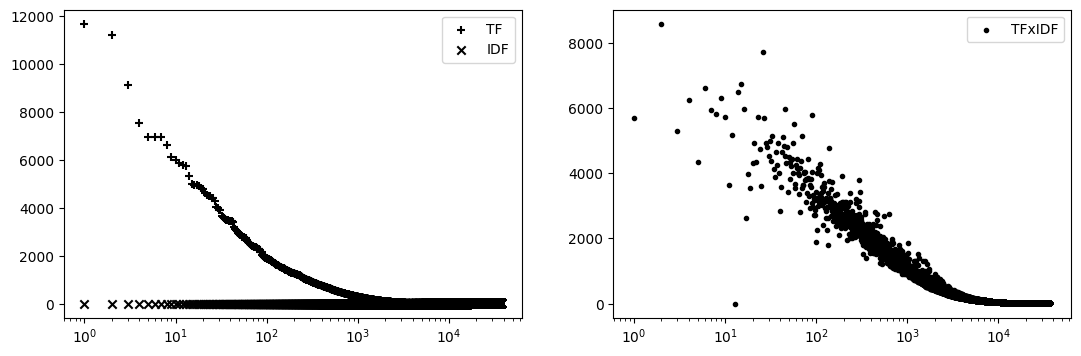

In [10]:
## START YOU CODE HERE

# TF = collection frequency
sorted_tf = dict(sorted(indexer.collection_freq.items(), key=lambda item: item[1], reverse=True))

# number of documents
N = len(indexer.doc_lengths)

# computing IDF
idf_dict = {term: math.log(N / df) for term, df in indexer.doc_freq.items()}

# sorting IDF in same order
sorted_idf = {term: idf_dict[term] for term in sorted_tf}

## END

# Scatter plot
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
x_values = list(range(1,len(sorted_tf)+1))
axs[0].scatter(x_values, sorted_tf.values(), color='black', marker='+', label='TF')
axs[0].scatter(x_values, sorted_idf.values(), color='black', marker='x', label='IDF')
axs[0].set_xscale('log')
axs[0].legend()

axs[1].scatter(x_values, [sorted_tf[key] * sorted_idf[key] for key in sorted_tf], color='black', marker='.', label='TFxIDF')
axs[1].set_xscale('log')
axs[1].legend()
plt.show()



What do you observe?

`Observation`: The scatter plots illustrate the relationship between Term Frequency (TF) and Inverse Document Frequency (IDF) across the document collection. The TF curve shows a steep decline as the rank increases, indicating that a small number of terms occur very frequently while most terms appear rarely, which follows the typical Zipf’s Law distribution in natural language. In contrast, IDF values remain relatively low for highly frequent terms because these words appear in many documents and therefore carry less discriminative power. As term frequency decreases, the importance of terms in distinguishing documents increases, which is reflected in higher IDF values. The TF×IDF plot further demonstrates that terms with extremely high frequency or extremely low frequency tend to have lower TF-IDF scores, while moderately frequent terms achieve higher TF-IDF values. This confirms that TF-IDF effectively balances term occurrence within documents and term uniqueness across the collection to identify informative terms for information retrieval.


# Retrieval

Now that we have successfully constructed the inverted index, the next step involves leveraging these components to respond to user queries using a boolean model.


### <span style="color:red"><b>TASK 4</b></span>

In this task, you will be tasked with implementing two crucial methods:

- `union_postings`: This method is designed to compute the union between two posting lists.
- `intersect_two_postings`: This method focuses on determining the intersection between two posting lists.

These functions play a pivotal role in the query processing pipeline, enabling the system to effectively combine and analyze the information stored in the inverted index for accurate and relevant query results.



In [11]:
class Retrieval:

    def __init__(self, indexer, prep):
        """
        Constructor for the Retrieval class.

        Parameters:
        - indexer: The inverted index and document frequency indexer.
        - prep: The preprocessor for query and document text.
        """
        self.indexer = indexer
        self.prep = prep

    def prepare_query(self, raw_query):
        """
        Preprocesses the raw query using the preprocessor and counts token frequencies.

        Parameters:
        - raw_query: The raw query string.

        Returns:
        A dictionary with token frequencies in the query.
        """
        # Pre-process query the same way as documents
        query = self.prep.preprocess(raw_query)
        # Count frequency
        return dict(Counter(query))

    def intersect_two_postings(self, posting_1, posting_2):
        """
        Computes the intersection between two posting lists.

        Parameters:
        - posting_1: The first posting list.
        - posting_2: The second posting list.

        Returns:
        A list containing the common elements between posting_1 and posting_2.
        """
        answer = []
        ## START YOU CODE HERE
        i = 0
        j = 0

        while i < len(posting_1) and j < len(posting_2):
          if posting_1[i] == posting_2[j]:
              answer.append(posting_1[i])
              i += 1
              j += 1

          elif posting_1[i] < posting_2[j]:
              i += 1

          else:
              j += 1
        ## END
        return answer

    def intersect_postings(self, postings, doc_freq):
        """
        Computes the intersection of multiple posting lists.

        Parameters:
        - postings: A dictionary of posting lists for each token.
        - doc_freq: A dictionary of document frequencies for each token.

        Returns:
        A sorted list of documents that satisfy the intersection condition.
        """
        sorted_docs = sorted(doc_freq, key=doc_freq.get)
        merge = list(postings[sorted_docs[0]].keys())
        for token in sorted_docs[1:]:
            merge = self.intersect_two_postings(merge, list(postings[token].keys()))
        return sorted(merge)

    def union_postings(self, postings):
        """
        Computes the union of multiple posting lists.

        Parameters:
        - postings: A dictionary of posting lists for each token.

        Returns:
        A sorted list of documents that satisfy the union condition.
        """
        answer = []
        ## START YOU CODE HERE
        docs = set()
        for token in postings:
          docs.update(postings[token].keys())

        answer = sorted(list(docs))
        ## END
        return answer

    def boolean_retrieval(self, query, ir_model='boolean', operator='OR'):
        """
        Performs boolean retrieval for the given query.

        Parameters:
        - query: The user query string.
        - ir_model: The information retrieval model to be used.
        - operator: The boolean operator ('AND' or 'OR') for combining query terms.

        Returns:
        A dictionary of sorted documents based on the relevance score.
        """
        query_tokens = self.prepare_query(query)
        postings = {}
        doc_freq = {}
        retrieved_docs = []
        for token in query_tokens.keys():
            if token in self.indexer.inverted_index.keys():
                postings[token] = self.indexer.inverted_index[token]
                doc_freq[token] = self.indexer.doc_freq[token]
            else:
                postings[token] = {}
                doc_freq[token] = 0
        if operator.lower() == 'and':
            retrieved_docs = self.intersect_postings(postings, doc_freq)
        elif operator.lower() == 'or':
            retrieved_docs =  self.union_postings(postings)
        else:
            raise ValueError('Incorrect Boolean operator.')

        if ir_model.lower() == 'boolean':
            return retrieved_docs


Let's test the implementation of your implementation of `union_postings` and `intersect_two_postings`  by executing the following cell:

In [12]:
indexer_test = Indexer(None)
indexer_test.inverted_index = {'x': {1: 1, 2: 1, 5: 3, 6: 1},
                          'y': {1: 1, 3: 1, 5: 1, 6: 1},
                          'z': {2: 1, 4: 2, 5: 3, 6: 1, 7: 3}}
indexer_test.collection_freq =  {'x': 6, 'y': 4, 'z': 10}
indexer_test.doc_freq = {'x': 4, 'y': 4, 'z': 5}
indexer_test.doc_lengths = {1: 20, 2: 15, 3: 10, 4:20, 5:30, 6:12, 7:22}

retrieval = Retrieval(indexer_test, prep)

# Testing the 'AND' operator
assert retrieval.boolean_retrieval('x y', operator='AND') == [1, 5, 6], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('x z', operator='AND') == [2, 5, 6], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('y z', operator='AND') == [5, 6], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('x y z', operator='AND') == [5, 6], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('y z b', operator='AND') == [], "Test failed!"
print("Success!")

# Testing the 'OR' operator
assert retrieval.boolean_retrieval('x y', operator='OR') == [1, 2, 3, 5, 6], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('x z', operator='OR') == [1, 2, 4, 5, 6, 7], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('y z', operator='OR') == [1, 2, 3, 4, 5, 6, 7], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('x y z', operator='OR') == [1, 2, 3, 4, 5, 6, 7], "Test failed!"
print("Success!")
assert retrieval.boolean_retrieval('x y b', operator='OR') == [1, 2, 3, 5, 6], "Test failed!"
print("Success!")


Success!
Success!
Success!
Success!
Success!
Success!
Success!
Success!
Success!
Success!


# Congratulations!


Congratulations on completing the assignment! Your dedication and effort are commendable. By successfully working through the coding exercises and written exercises, you have demonstrated a strong understanding of the concepts and principles related Information Retrieval.


Congratulations on finishing this notebook!




# Acknowledgement

## About the Author

This notebook was authored by Mohamed Reda Bouadjenek. He is a Senior Lecturer (Assistant Professor) of Applied Artificial Intelligence in the School of Information Technology at Deakin University, Australia.

## Contact Information

- **Email:** reda.bouadjenek@deakin.edu.au
- **GitHub:** https://github.com/rbouadjenek/

---
